In [1]:
import giggle_my_version as giggle
import numpy as np 
import matplotlib.pyplot as plt

import math
#from scipy import ndimage as ndimage
import disk_ecc_spiral as disk
import disk_ecc as kevindisk
#import disk_ecc_spiral_pp as proto
#from astropy import units as u
#from astropy.constants import G, sigma_sb, k_B, m_p

from astropy.io import fits
import bettermoments as bm

#from scipy.interpolate import LinearNDInterpolator as interpnd

In [2]:
Rc = 123
log_stellar = .18904
log_mass = -4.263
pp = -4

In [4]:
'''
m_list = np.array([1,2])
ap_list = np.array([10,20,30])
pos_list = np.array([0,60,120,180])

for i in range(len(m_list)):
    for j in range(len(ap_list)):
        for k in range(len(pos_list)):
            bunit_add = fits.open('fits_files/spiral_incl84_ap{}_m{}_pos{}.fits'.format(ap_list[j], m_list[i], pos_list[k]), mode="update")
            bunit_add["PRIMARY"].header["BUNIT"] = 'Jy' 
            bunit_add.flush()
            bunit_add.close()

            path = 'fits_files/spiral_incl84_ap{}_m{}_pos{}.fits'.format(ap_list[j], m_list[i], pos_list[k])
            data, velax = bm.load_cube(path)
            rms = bm.estimate_RMS(data=data, N=1)
            m0 = bm.collapse_zeroth(velax=velax, data=data, rms=rms)
            bm.save_to_FITS(moments=m0, method='zeroth', path=path)

            spiral = fits.open('fits_files/spiral_incl84_ap{}_m{}_pos{}_M0.fits'.format(ap_list[j], m_list[i], pos_list[k]))
            spiral_data = spiral["PRIMARY"].data

            fig, ax = plt.subplots()
            plt.imshow(spiral_data, vmin=0, vmax=2, extent=[0,25.6,0,25.6])
            plt.colorbar(label="Jy km/s")
            ax.set_xlabel("arcsec")
            ax.set_ylabel("arcsec")
'''

'\nm_list = np.array([1,2])\nap_list = np.array([10,20,30])\npos_list = np.array([0,60,120,180])\n\nfor i in range(len(m_list)):\n    for j in range(len(ap_list)):\n        for k in range(len(pos_list)):\n            bunit_add = fits.open(\'fits_files/spiral_incl84_ap{}_m{}_pos{}.fits\'.format(ap_list[j], m_list[i], pos_list[k]), mode="update")\n            bunit_add["PRIMARY"].header["BUNIT"] = \'Jy\' \n            bunit_add.flush()\n            bunit_add.close()\n\n            path = \'fits_files/spiral_incl84_ap{}_m{}_pos{}.fits\'.format(ap_list[j], m_list[i], pos_list[k])\n            data, velax = bm.load_cube(path)\n            rms = bm.estimate_RMS(data=data, N=1)\n            m0 = bm.collapse_zeroth(velax=velax, data=data, rms=rms)\n            bm.save_to_FITS(moments=m0, method=\'zeroth\', path=path)\n\n            spiral = fits.open(\'fits_files/spiral_incl84_ap{}_m{}_pos{}_M0.fits\'.format(ap_list[j], m_list[i], pos_list[k]))\n            spiral_data = spiral["PRIMARY"].data

In [ ]:
bunit_add = fits.open("84_incl_kep.fits", mode="update")
bunit_add["PRIMARY"].header["BUNIT"] = 'Jy' 
bunit_add.flush()
bunit_add.close()

kep = fits.open("84_incl_kep.fits")
kep_data = kep["PRIMARY"].data

In [ ]:
for i in range(len(m_list)):
    for j in range(len(ap_list)):
        for k in range(len(pos_list)):

            spiral = fits.open('fits_files/spiral_incl84_ap{}_m{}_pos{}.fits'.format(ap_list[j], m_list[i], pos_list[k]))
            spiral_data = spiral["PRIMARY"].data

            resid = spiral_data-kep_data

            fits.writeto("fits_files/resid_fits/resid_incl84_ap{}_m{}_pos{}.fits".format(ap_list[j], m_list[i], pos_list[k]), resid, kep_hires["PRIMARY"].header)

            path = "fits_files/resid_fits/resid_incl84_ap{}_m{}_pos{}.fits".format(ap_list[j], m_list[i], pos_list[k])
            data, velax = bm.load_cube(path)
            rms = bm.estimate_RMS(data=data, N=1)
            m0 = bm.collapse_zeroth(velax=velax, data=data, rms=rms)
            bm.save_to_FITS(moments=m0, method='zeroth', path="fits_files/resid_fits/resid_m0/resid_incl84_ap{}_m{}_pos{}.fits".format(ap_list[j], m_list[i], pos_list[k]))

            resid_fits = fits.open("fits_files/resid_fits/resid_m0/resid_incl84_ap{}_m{}_pos{}_M0.fits".format(ap_list[j], m_list[i], pos_list[k]))
            resid_fits_data = resid_fits["PRIMARY"].data

            fig, ax = plt.subplots()
            plt.imshow(resid_fits_data, vmin=0, vmax=2, extent=[0,25.6,0,25.6])
            plt.colorbar(label="Jy km/s")
            ax.set_xlabel("arcsec")
            ax.set_ylabel("arcsec")

In [ ]:
for i in range(len(m_list)):
    for j in range(len(ap_list)):
        for k in range(len(pos_list)):
            path = "fits_files/resid_fits/resid_incl84_ap{}_m{}_pos{}.fits".format(ap_list[j], m_list[i], pos_list[k])
            data, velax = bm.load_cube(path)
            rms = bm.estimate_RMS(data=data, N=1)
            m0 = bm.collapse_first(velax=velax, data=data, rms=rms)
            bm.save_to_FITS(moments=m1, method='first', path="fits_files/resid_fits/resid_m0/resid_incl84_ap{}_m{}_pos{}.fits".format(ap_list[j], m_list[i], pos_list[k]))

            resid_fits1 = fits.open("fits_files/resid_fits/resid_m1/resid_incl84_ap{}_m{}_pos{}_M1.fits".format(ap_list[j], m_list[i], pos_list[k]))
            resid_fits_data1 = resid_fits["PRIMARY"].data

            fig, ax = plt.subplots()
            plt.imshow(resid_fits_data1, vmin=0, vmax=2, extent=[0,25.6,0,25.6])
            plt.colorbar(label="Jy km/s")
            ax.set_xlabel("arcsec")
            ax.set_ylabel("arcsec")

In [17]:
%run raytrace_spiral.py

In [5]:
'''
m_list = np.array([1,2])
ap_list = np.array([10,20,30])
pos_list = np.array([0,60,120,180])

for i in range(len(m_list)):
    for j in range(len(ap_list)):
        for k in range(len(pos_list)):
            x = disk.Disk(Aout=5*Rc,incl=84, Mstar=10**log_stellar, Ain=19, proto=False, md=.5, ap=ap_list[j], m=m_list[i], pp=pp, Rc=Rc, surf_amp=.5, sigbound=[1e-3,np.inf], Tmid0=12.5, zmax=30, McoG=10**log_mass,Tatm0=12.5, q=-0.42, pos=pos_list[k])
            total_model(x,imres=0.05,distance=30.,chanmin=-2.24,nchans=30,chanstep=0.16,flipme=False,Jnum=2,freq0=345.79599,xnpix=512,vsys=0,PA=-71.4,offs=[0.0,0.0],
                modfile='fits_files/spiral_incl84_ap{}_m{}_pos{}'.format(ap_list[j], m_list[i], pos_list[k]),abund=1.,obsv=None,wind=False,isgas=True,includeDust=False,extra=0,bin=1,hanning=False,
                L_cloud=False, tau = [0,], sigma_c = [6,], velocity_c =[2,],manual_chan_params=False,response_function=False)
'''

"\nm_list = np.array([1,2])\nap_list = np.array([10,20,30])\npos_list = np.array([0,60,120,180])\n\nfor i in range(len(m_list)):\n    for j in range(len(ap_list)):\n        for k in range(len(pos_list)):\n            x = disk.Disk(Aout=5*Rc,incl=84, Mstar=10**log_stellar, Ain=19, proto=False, md=.5, ap=ap_list[j], m=m_list[i], pp=pp, Rc=Rc, surf_amp=.5, sigbound=[1e-3,np.inf], Tmid0=12.5, zmax=30, McoG=10**log_mass,Tatm0=12.5, q=-0.42, pos=pos_list[k])\n            total_model(x,imres=0.05,distance=30.,chanmin=-2.24,nchans=30,chanstep=0.16,flipme=False,Jnum=2,freq0=345.79599,xnpix=512,vsys=0,PA=-71.4,offs=[0.0,0.0],\n                modfile='fits_files/spiral_incl84_ap{}_m{}_pos{}'.format(ap_list[j], m_list[i], pos_list[k]),abund=1.,obsv=None,wind=False,isgas=True,includeDust=False,extra=0,bin=1,hanning=False,\n                L_cloud=False, tau = [0,], sigma_c = [6,], velocity_c =[2,],manual_chan_params=False,response_function=False)\n"

g_phi max3.140341089787712
g_phi min-3.140341089787712


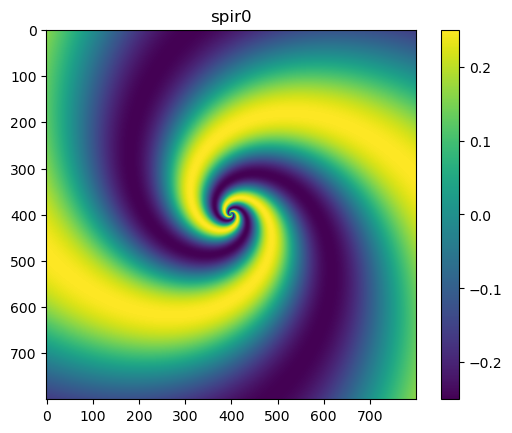

g_r_tiled.shape (1920000,)
g_phi_tiled.shape (1920000,)
tile max 9.423526396967299
tile min 3.142844217391874


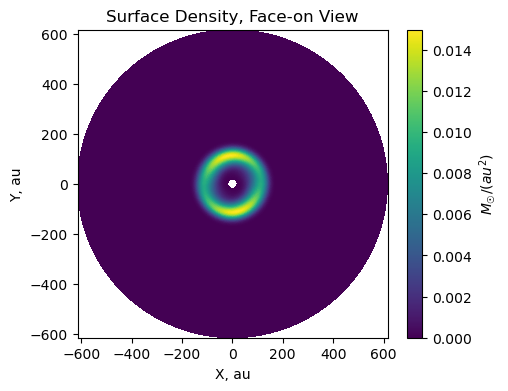

6.210132776522376e-17
rho0 max 6.210132776522376e-17
phi_vel shape (800, 800)
phi_flat-vel length640000
tempg max 25.109236115296312


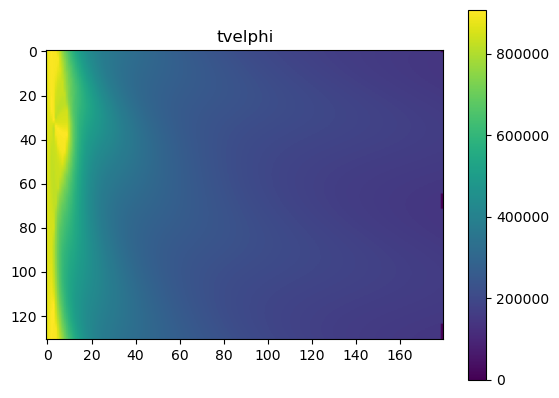

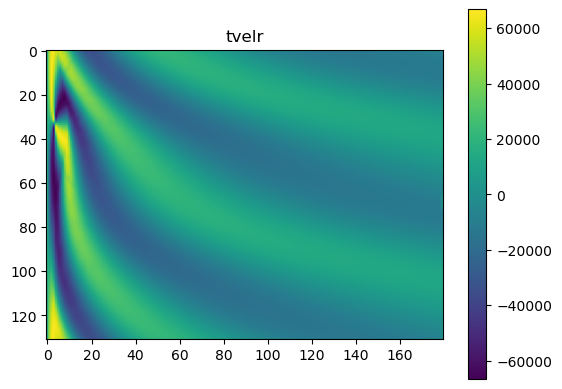

In [2]:
'''testing disk model'''

#x = disk.Disk(zmax=10)
#testing with elias disk parameters to match logarini

Rc = 123
log_stellar = .18904
log_mass = -4.263
pp = -4

'''testing with params of longarini 2021 moment 1 map
leaving default pp temp structure. Need to check on surface density definition and crit radius def'''
#x = disk.Disk(Tmid0=14, Rc=50., sigbound=[1e-3,np.inf],zmax=30, McoG=1e-4, Aout=1000.,incl=30.)
x = disk.Disk(Aout=5*Rc,incl=20, Mstar=10**log_stellar, Ain=19, proto=False, md=.2, ap=30, m=2, pp=pp, Rc=Rc, surf_amp=.5, sigbound=[1e-3,np.inf], Tmid0=12.5, zmax=30, McoG=10**log_mass,Tatm0=12.5, q=-0.42, pos=45)

1d z-array [1.49597871e+12 1.85410331e+12 2.21222792e+12 ... 4.48077363e+14
 4.48435487e+14 4.48793612e+14]
(500, 131, 1250)


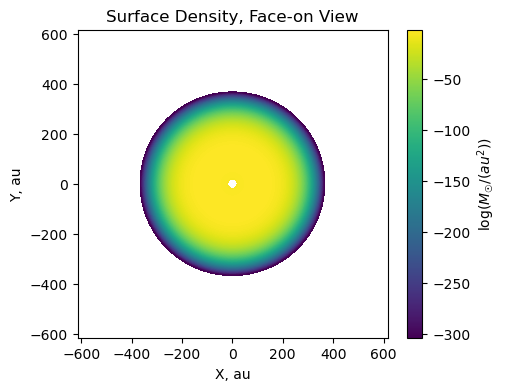

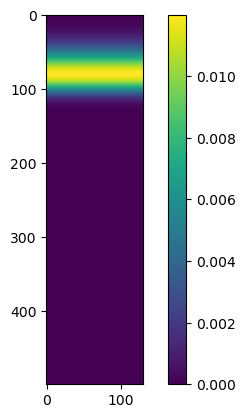

siggas[[1.74262646e-05 1.74262646e-05 1.74262646e-05 ... 1.74262646e-05
  1.74262646e-05 1.74262646e-05]
 [2.22387383e-05 2.22387383e-05 2.22387383e-05 ... 2.22387383e-05
  2.22387383e-05 2.22387383e-05]
 [2.79851505e-05 2.79851505e-05 2.79851505e-05 ... 2.79851505e-05
  2.79851505e-05 2.79851505e-05]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]


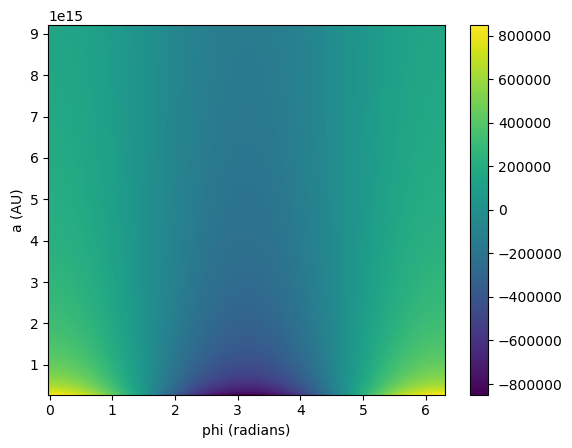

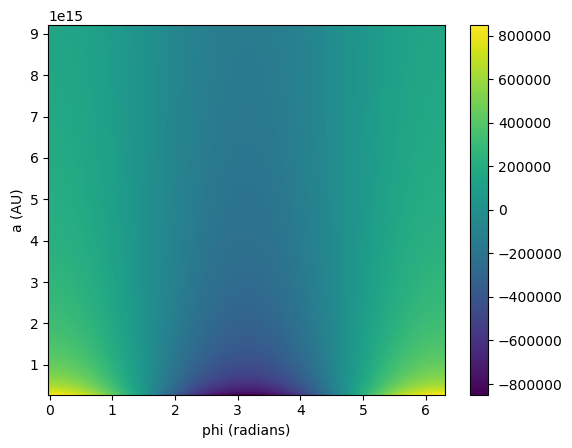

self.vel min -849447.0462125608
self.vel max849447.0462125608
self.vel mean 1942.4897586874772


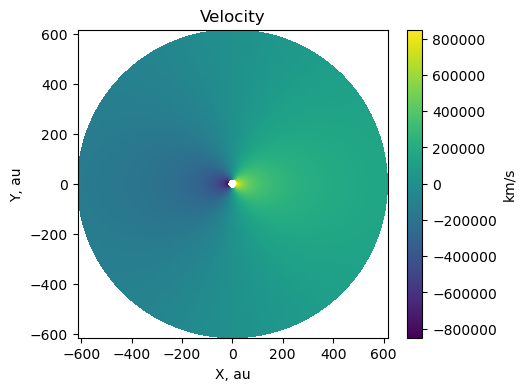

R min0.0
R max9200269048050000.0
phi min0.0
phi max6.283185307179586


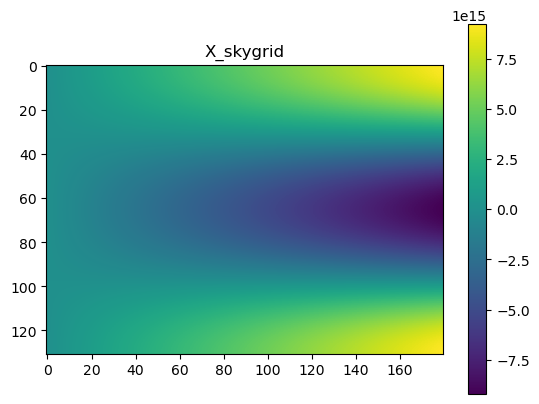

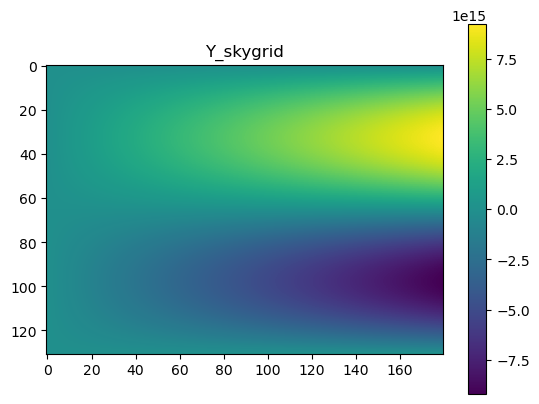

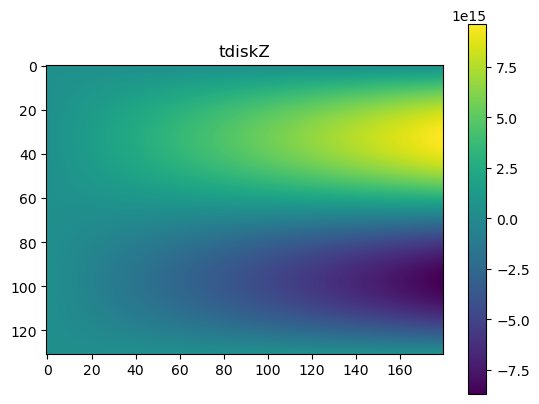

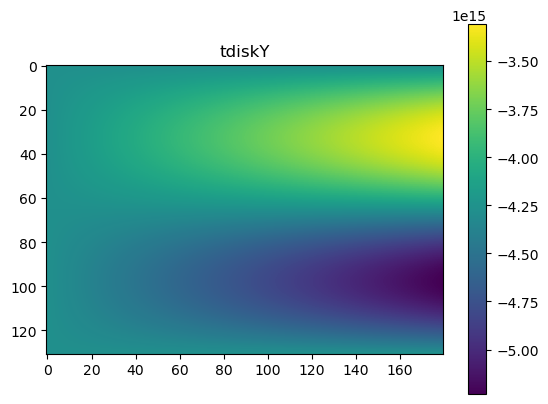

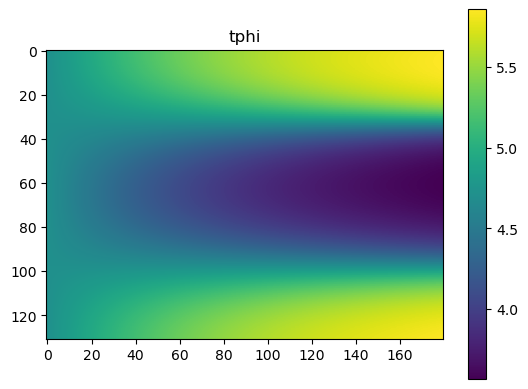

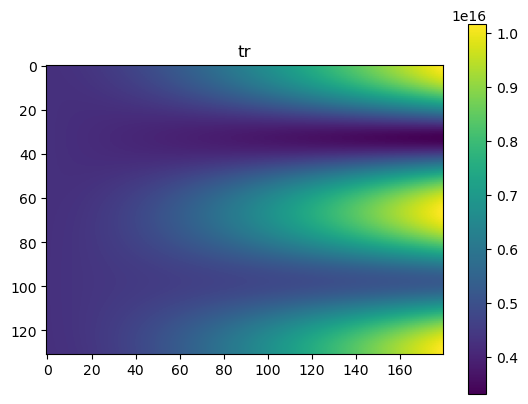

zind min 0.0
zind max 1249.0
zind mean 1153.2644202585757
phiind min 0.0
phiind max 130.0
phiind mean 65.1081132095835
aind min 0.0
aind max 500.0
aind mean 209.1096737029533


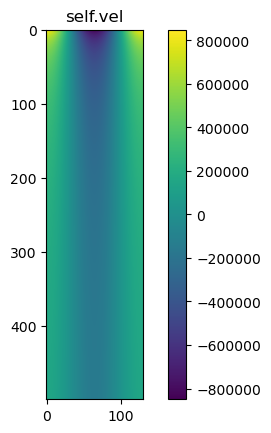

self.vel min -849447.0462125608
self.vel max 849447.0462125608


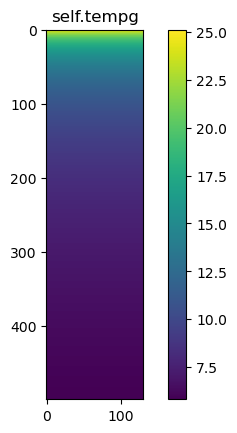

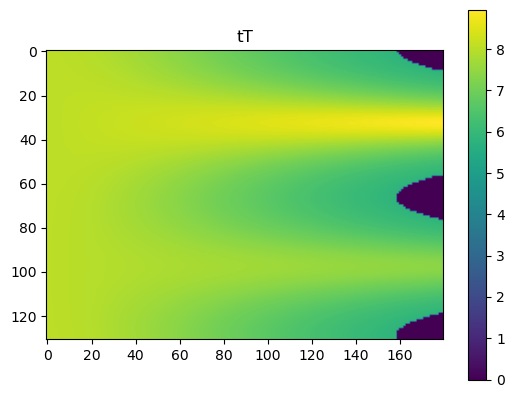

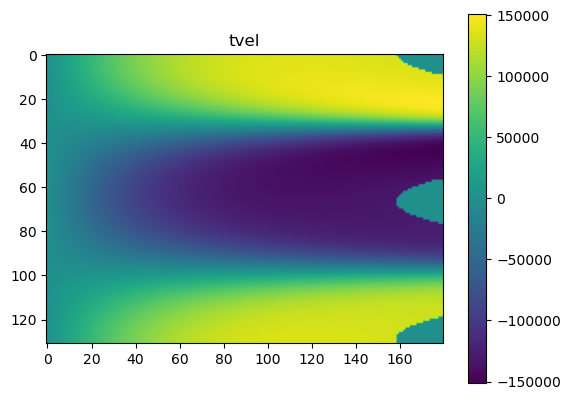

tvel.shape (131, 180, 300)
tvel min -849447.0462125608


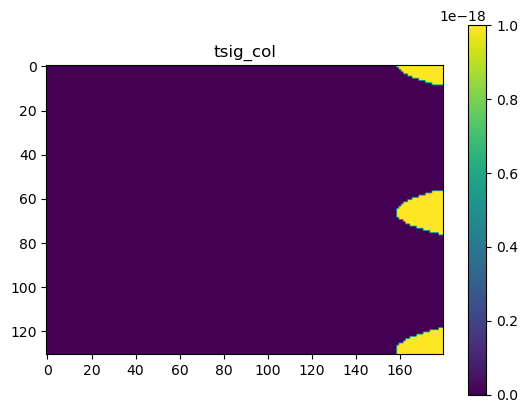

zpht_up shape (131, 180, 300)


In [4]:
#y = kevindisk.Disk(zmax=10)
y = kevindisk.Disk(Aout=5*Rc,incl=84, Mstar=10**log_stellar, Ain=19, pp=pp, Rc=Rc, sigbound=[1e-3,np.inf], Tmid0=12.5, zmax=30, McoG=10**log_mass,Tatm0=12.5, q=-0.42)

In [3]:
%run raytrace.py
total_model(y,imres=0.05,distance=30.,chanmin=-2.24,nchans=30,chanstep=0.16,flipme=False,Jnum=2,freq0=345.79599,xnpix=512,vsys=0,PA=-71.4,offs=[0.0,0.0],
                modfile='fits_files/84_incl_kep',abund=1.,obsv=None,wind=False,isgas=True,includeDust=False,extra=0,bin=1,hanning=False,
                L_cloud=False, tau = [0,], sigma_c = [6,], velocity_c =[2,],manual_chan_params=False,response_function=False)

NameError: name 'y' is not defined

In [3]:
%run raytrace_spiral.py

cube.shape (131, 180, 30)
disk.X shape (131, 180)
disk.Y shape (131, 180)
disk.X shape (131, 180)
rhoG max 1251.7385286272413
rhoG shape (131, 180, 300)
signuF1 5.113762129885244e-11
disk.dBV[[[   0.            0.            0.         ...    0.
      0.            0.        ]
  [   0.            0.            0.         ...    0.
      0.            0.        ]
  [   0.            0.            0.         ...    0.
      0.            0.        ]
  ...
  [5875.22150448 5875.2241453  5875.22676846 ... 5875.22937397
   5875.22676846 5875.2241453 ]
  [5868.27665399 5868.27926126 5868.28185109 ... 5868.28442349
   5868.28185109 5868.27926126]
  [   0.            0.            0.         ...    0.
      0.            0.        ]]

 [[   0.            0.            0.         ...    0.
      0.            0.        ]
  [   0.            0.            0.         ...    0.
      0.            0.        ]
  [   0.            0.            0.         ...    0.
      0.            0.        ]
  

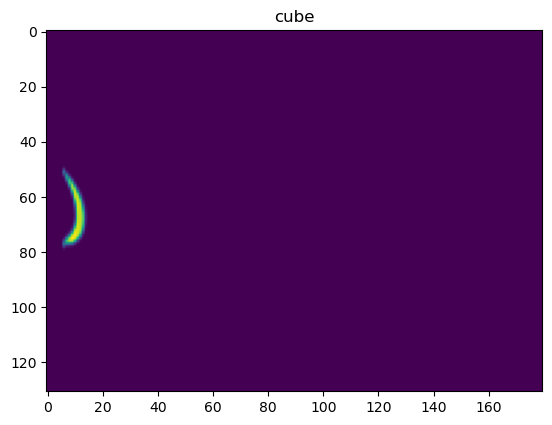

signuF1 5.1137512129095515e-11
disk.dBV[[[   0.            0.            0.         ...    0.
      0.            0.        ]
  [   0.            0.            0.         ...    0.
      0.            0.        ]
  [   0.            0.            0.         ...    0.
      0.            0.        ]
  ...
  [5875.22150448 5875.2241453  5875.22676846 ... 5875.22937397
   5875.22676846 5875.2241453 ]
  [5868.27665399 5868.27926126 5868.28185109 ... 5868.28442349
   5868.28185109 5868.27926126]
  [   0.            0.            0.         ...    0.
      0.            0.        ]]

 [[   0.            0.            0.         ...    0.
      0.            0.        ]
  [   0.            0.            0.         ...    0.
      0.            0.        ]
  [   0.            0.            0.         ...    0.
      0.            0.        ]
  ...
  [5876.39625112 5876.39217792 5876.388087   ... 5874.41304692
   5874.40374665 5874.39442878]
  [5869.4447931  5869.44073423 5869.43665787 ... 5867

In [4]:
#otal_model(x, modfile="whynans")

#%run raytrace.py
total_model(x,imres=0.05,distance=30.,chanmin=-2.24,nchans=30,chanstep=0.16,flipme=False,Jnum=2,freq0=345.79599,xnpix=512,vsys=0,PA=-71.4,offs=[0.0,0.0],
                modfile='fits_files/20_incl_spiral',abund=1.,obsv=None,wind=False,isgas=True,includeDust=False,extra=0,bin=1,hanning=False,
                L_cloud=False, tau = [0,], sigma_c = [6,], velocity_c =[2,],manual_chan_params=False,response_function=False)